In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import WeightedRandomSampler

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (confusion_matrix, classification_report, matthews_corrcoef,
							accuracy_score, precision_score, recall_score, f1_score)

In [2]:
import random
# setting seed so the results are consistently reproducible
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [3]:
train=pd.read_csv("../data/preprocessedTrain.csv")
test=pd.read_csv("../data/preprocessedTest.csv")

In [4]:
# To fill nulls
train['f_Header_b_payload_Ratio'] = train['f_Header_b_payload_Ratio'].replace(np.nan, train['f_Header_b_payload_Ratio'].max() + 1) 
train['b_Header_f_payload_Ratio'] = train['b_Header_f_payload_Ratio'].replace(np.nan, train['b_Header_f_payload_Ratio'].max() + 1) 
test['f_Header_b_payload_Ratio'] = test['f_Header_b_payload_Ratio'].replace(np.nan, test['f_Header_b_payload_Ratio'].max() + 1) 
test['b_Header_f_payload_Ratio'] = test['b_Header_f_payload_Ratio'].replace(np.nan, test['b_Header_f_payload_Ratio'].max() + 1)

In [5]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train class counts:\n", train["Attack_type"].value_counts())
print("Test class counts:\n", test["Attack_type"].value_counts())

Train shape: (98493, 84)
Test shape: (24624, 84)
Train class counts:
 Attack_type
DOS_SYN_Hping                 75727
Thing_Speak                    6486
ARP_poisioning                 6200
MQTT_Publish                   3317
NMAP_UDP_SCAN                  2072
NMAP_XMAS_TREE_SCAN            1608
NMAP_OS_DETECTION              1600
NMAP_TCP_scan                   802
DDOS_Slowloris                  427
Wipro_bulb                      202
Metasploit_Brute_Force_SSH       30
NMAP_FIN_SCAN                    22
Name: count, dtype: int64
Test class counts:
 Attack_type
DOS_SYN_Hping                 18932
Thing_Speak                    1622
ARP_poisioning                 1550
MQTT_Publish                    829
NMAP_UDP_SCAN                   518
NMAP_XMAS_TREE_SCAN             402
NMAP_OS_DETECTION               400
NMAP_TCP_scan                   200
DDOS_Slowloris                  107
Wipro_bulb                       51
Metasploit_Brute_Force_SSH        7
NMAP_FIN_SCAN                   

# Multi-Class Classification Model

In [6]:
# Multi class classification
label_encoder = LabelEncoder().fit(train["Attack_type"])

y_train = label_encoder.transform(train["Attack_type"])
y_test = label_encoder.transform(test["Attack_type"])

# Get class names for later
class_names = label_encoder.classes_
print(f"Number of classes: {len(class_names)}")
print(f"Classes: {class_names}")

X_train = train.drop("Attack_type", axis=1)
X_test = test.drop("Attack_type", axis=1).values

Number of classes: 12
Classes: ['ARP_poisioning' 'DDOS_Slowloris' 'DOS_SYN_Hping' 'MQTT_Publish'
 'Metasploit_Brute_Force_SSH' 'NMAP_FIN_SCAN' 'NMAP_OS_DETECTION'
 'NMAP_TCP_scan' 'NMAP_UDP_SCAN' 'NMAP_XMAS_TREE_SCAN' 'Thing_Speak'
 'Wipro_bulb']


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
X_val = X_val.values

### SMOTENC

In [ ]:
values, counts = np.unique(y_train, return_counts=True)
print(values)  
print(counts) 

[ 0  1  2  3  4  5  6  7  8  9 10 11]
[ 4960   342 60581  2653    24    18  1280   642  1657  1286  5189   162]


In [9]:
# put the ports back to one col.
mapping = {
    (1,0): 'icmp',
    (0,1): 'tcp',
    (0,0): 'udp'
}

X_train['proto'] = list(zip(X_train.proto_icmp, X_train.proto_tcp))
X_train['proto'] = X_train['proto'].map(mapping)
X_train = X_train.drop(['proto_icmp','proto_tcp'],axis=1)

smote = SMOTENC(random_state=42,categorical_features=[2,81],sampling_strategy={0: np.rint(4960*1.2,).astype(int),
                                                                            1: np.rint(342*2).astype(int),
                                                                            2: np.rint(60581).astype(int),
                                                                            3: np.rint(2653*1.5).astype(int),
                                                                            4: np.rint(24*3).astype(int),
                                                                            5: np.rint(18*3).astype(int),
                                                                            6: np.rint(1280*1.75).astype(int),
                                                                            7: np.rint(642*2).astype(int),
                                                                            8: np.rint(1657*1.5).astype(int),
                                                                            9: np.rint(1286*1.75).astype(int),
                                                                            10: np.rint(5189*1.2).astype(int),
                                                                            11: np.rint(162*2).astype(int)})
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
X_train_res = pd.get_dummies(X_train_res)
X_train_res = X_train_res.drop(['proto_udp'],axis=1)

# need to reorder back to original ordering
cols = list(X_train_res.columns)
col1 = cols.pop(81)  #icmp
col2 = cols.pop(81)  #tcp
cols.insert(77, col2)
cols.insert(77, col1)
X_train_res = X_train_res[cols]

X_train_res=X_train_res.values
X_train_res = X_train_res.astype(np.float32)


In [10]:
X_train_tensor = torch.tensor(X_train_res, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_res, dtype=torch.long) 

# TEST
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long) 

# Validation
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long) 

In [11]:
X_train_tensor = X_train_tensor.unsqueeze(1)
X_test_tensor = X_test_tensor.unsqueeze(1)
X_val_tensor = X_val_tensor.unsqueeze(1)

In [12]:
y = np.array(y_train_res)
class_counts = np.bincount(y)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),replacement=True)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, sampler=sampler)
test_loader = DataLoader(test_dataset, batch_size=64)
val_loader = DataLoader(val_dataset, batch_size=64)

#### Export val for use in quantizer

In [14]:
# 308,64,1,83

x_val_list = []
y_val_list = []
for x, y in val_loader:  # your validation DataLoader
    x_val_list.append(x.numpy())   # convert tensor -> np array
    y_val_list.append(y.numpy())

x_val_all = np.concatenate(x_val_list, axis=0)   # shape: (num_samples, 1, 83)
y_val_all = np.concatenate(y_val_list, axis=0) 
print(len(x_val_all))
np.save("val_inputs.npy", x_val_all)   
np.save("val_labels.npy", y_val_all)   

print("Validation dataset saved!")


19699
Validation dataset saved!


In [ ]:
# input data format (batch_size, sequence_length, num_features)
# (batch, 1, 83) 
# the sequence represents temporal ordering...this would exist in real-time situation
class MultiClass2dCNN(nn.Module):
    def __init__(self, num_features=83, num_classes=12, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(1,3), padding=(0,1))
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(1,3), padding=(0,1))
        
        self.pool = nn.AvgPool2d((1,2))
        self.fc1 = nn.Linear(32*(num_features//2),128)
        self.dropout = nn.Dropout1d(.3)
        self.fc2 = nn.Linear(128,num_classes)

    def forward(self,x):
        # convolutions
        x = x.view(x.size(0), 1, 1, 83)

        x = F.relu(self.conv2(F.relu(self.conv1(x))))
        x = self.pool(x)
        # dense layers
        x = x.reshape(x.size(0),-1)
        x = self.fc2(self.dropout(F.relu(self.fc1(x))))

        return x

In [38]:
# Check if gpu is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


model = MultiClass2dCNN()
model = model.to(device) 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Using device: cpu


In [ ]:
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    print("start epoch")

    for batch, (X_batch, y_batch) in enumerate(train_loader):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
        running_loss += loss.item()


    print(f"Epoch [{epoch+1}/{num_epochs}], Avg Loss: {total_loss / len(train_loader):.4f}")

start epoch
Epoch [1/20], Avg Loss: 0.8120
start epoch
Epoch [2/20], Avg Loss: 0.7996
start epoch
Epoch [3/20], Avg Loss: 0.8033
start epoch
Epoch [4/20], Avg Loss: 0.8032
start epoch
Epoch [5/20], Avg Loss: 0.7983
start epoch
Epoch [6/20], Avg Loss: 0.7929
start epoch
Epoch [7/20], Avg Loss: 0.7944
start epoch
Epoch [8/20], Avg Loss: 0.7927
start epoch
Epoch [9/20], Avg Loss: 0.7963
start epoch
Epoch [10/20], Avg Loss: 0.7894
start epoch
Epoch [11/20], Avg Loss: 0.7843
start epoch
Epoch [12/20], Avg Loss: 0.7924
start epoch
Epoch [13/20], Avg Loss: 0.7828
start epoch
Epoch [14/20], Avg Loss: 0.7867
start epoch
Epoch [15/20], Avg Loss: 0.7827
start epoch
Epoch [16/20], Avg Loss: 0.7904
start epoch
Epoch [17/20], Avg Loss: 0.7868
start epoch
Epoch [18/20], Avg Loss: 0.7820
start epoch
Epoch [19/20], Avg Loss: 0.7830
start epoch
Epoch [20/20], Avg Loss: 0.7859


In [43]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 1395     1     0     0    21    15     0     0    47     2    67     2]
 [    1   103     0     0     0     0     0     0     3     0     0     0]
 [    0     0 18932     0     0     0     0     0     0     0     0     0]
 [    1     0     0   825     0     0     0     0     2     0     1     0]
 [    1     0     0     0     6     0     0     0     0     0     0     0]
 [    1     0     0     0     0     0     0     0     5     0     0     0]
 [    0     0     0     0     0     0     0     0   400     0     0     0]
 [    0     0     0     0     0     0     0     0   200     0     0     0]
 [    3    15     0     0     1     0     0     0   497     0     2     0]
 [    1     0     0     0     0     1     0     0   400     0     0     0]
 [   27     3     0     0     8     1     0     0     2     0  1574     7]
 [    1     0     0     0     0     0     0     0     7     0     0    43]]
                            precision    recall  f1-score   support

            ARP_poisioning    

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

---
# Inference

In [22]:
def load_model(model_path, device):
    model = MultiClass2dCNN()
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print("Model loaded successfully.")
    return model


model2=load_model(r"2dcnn_multiclass.pth",'cpu')

Model loaded successfully.


In [ ]:
x_test_list = []
y_test_list = []
for x, y in test_loader:  # your validation DataLoader
    x_test_list.append(x.numpy())   # convert tensor -> np array
    y_test_list.append(y.numpy())

x_test_all = np.concatenate(x_test_list, axis=0)   # shape: (num_samples, 1, 83)
y_test_all = np.concatenate(y_test_list, axis=0) 
print(len(x_test_all))
np.save("test_multi_inputs.npy", x_test_all)   
np.save("test_multi_labels.npy", y_test_all)   

print("Test dataset saved!")

In [70]:
inputData = torch.from_numpy(x_test_all[2]).float().unsqueeze(0)  #(1,83)\
import timeit
with torch.no_grad():
    total_time = timeit.timeit(lambda: model2(inputData), number=5000)

print(f"Per sample average: {(total_time/5000)*1000:.6f} ms")

Per sample average: 0.942577 ms


### TEST

In [ ]:
model2.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        outputs = model2(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

print(confusion_matrix(all_labels, all_preds))
print(classification_report(all_labels, all_preds, target_names=class_names))

[[ 1154     4     0     1    60     0     1     1     0     0    18     1]
 [    1    84     0     0     0     0     0     0     0     0     0     0]
 [    0     0 15146     0     0     0     0     0     0     0     0     0]
 [    0     0     0   664     0     0     0     0     0     0     0     0]
 [    1     0     0     0     5     0     0     0     0     0     0     0]
 [    1     0     0     0     0     3     0     0     0     0     0     0]
 [    0     0     0     0     0     0   320     0     0     0     0     0]
 [    0     0     0     0     0     0     0   160     0     0     0     0]
 [    2    22     0     0     4     0     0     0   384     0     3     0]
 [    0     0     0     0     0     0     0     0     0   322     0     0]
 [   47     1     0     0     6     1     0     0     3     0  1230     9]
 [    2     0     0     0     0     0     0     0     0     0     1    37]]
                            precision    recall  f1-score   support

            ARP_poisioning    

In [ ]:
# Convert to DataFrame and save as CSV
report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv("classification_reports/evaluation_metrics_2d_cnn_multi.csv", index=True)
print("Success")

Success


c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

In [45]:
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='macro')
rec = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')
precw = precision_score(all_labels, all_preds, average='weighted')
recw = recall_score(all_labels, all_preds, average='weighted')
f1w = f1_score(all_labels, all_preds, average='weighted')
mcc = matthews_corrcoef(all_labels, all_preds)


print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"\nOverall Metrics:")
print(f"Accuracy: {acc:.4f}")
print(f"Macro Precision: {prec:.4f}")
print(f"Macro Recall: {rec:.4f}")
print(f"Macro F1 Score: {f1:.4f}")
print(f"Weighted Precision: {precw:.4f}")
print(f"Weighted Recall: {recw:.4f}")
print(f"Weighted F1 Score: {f1w:.4f}")
print(f"MCC Score: {mcc:.4f}")


Classification Report:
                            precision    recall  f1-score   support

            ARP_poisioning       0.97      0.90      0.94      1550
            DDOS_Slowloris       0.84      0.96      0.90       107
             DOS_SYN_Hping       1.00      1.00      1.00     18932
              MQTT_Publish       1.00      1.00      1.00       829
Metasploit_Brute_Force_SSH       0.17      0.86      0.28         7
             NMAP_FIN_SCAN       0.00      0.00      0.00         6
         NMAP_OS_DETECTION       0.00      0.00      0.00       400
             NMAP_TCP_scan       0.00      0.00      0.00       200
             NMAP_UDP_SCAN       0.32      0.96      0.48       518
       NMAP_XMAS_TREE_SCAN       0.00      0.00      0.00       402
               Thing_Speak       0.96      0.97      0.96      1622
                Wipro_bulb       0.83      0.84      0.83        51

                  accuracy                           0.95     24624
                 macro

c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\willo_jlqcl0r\miniconda3\envs\caps\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

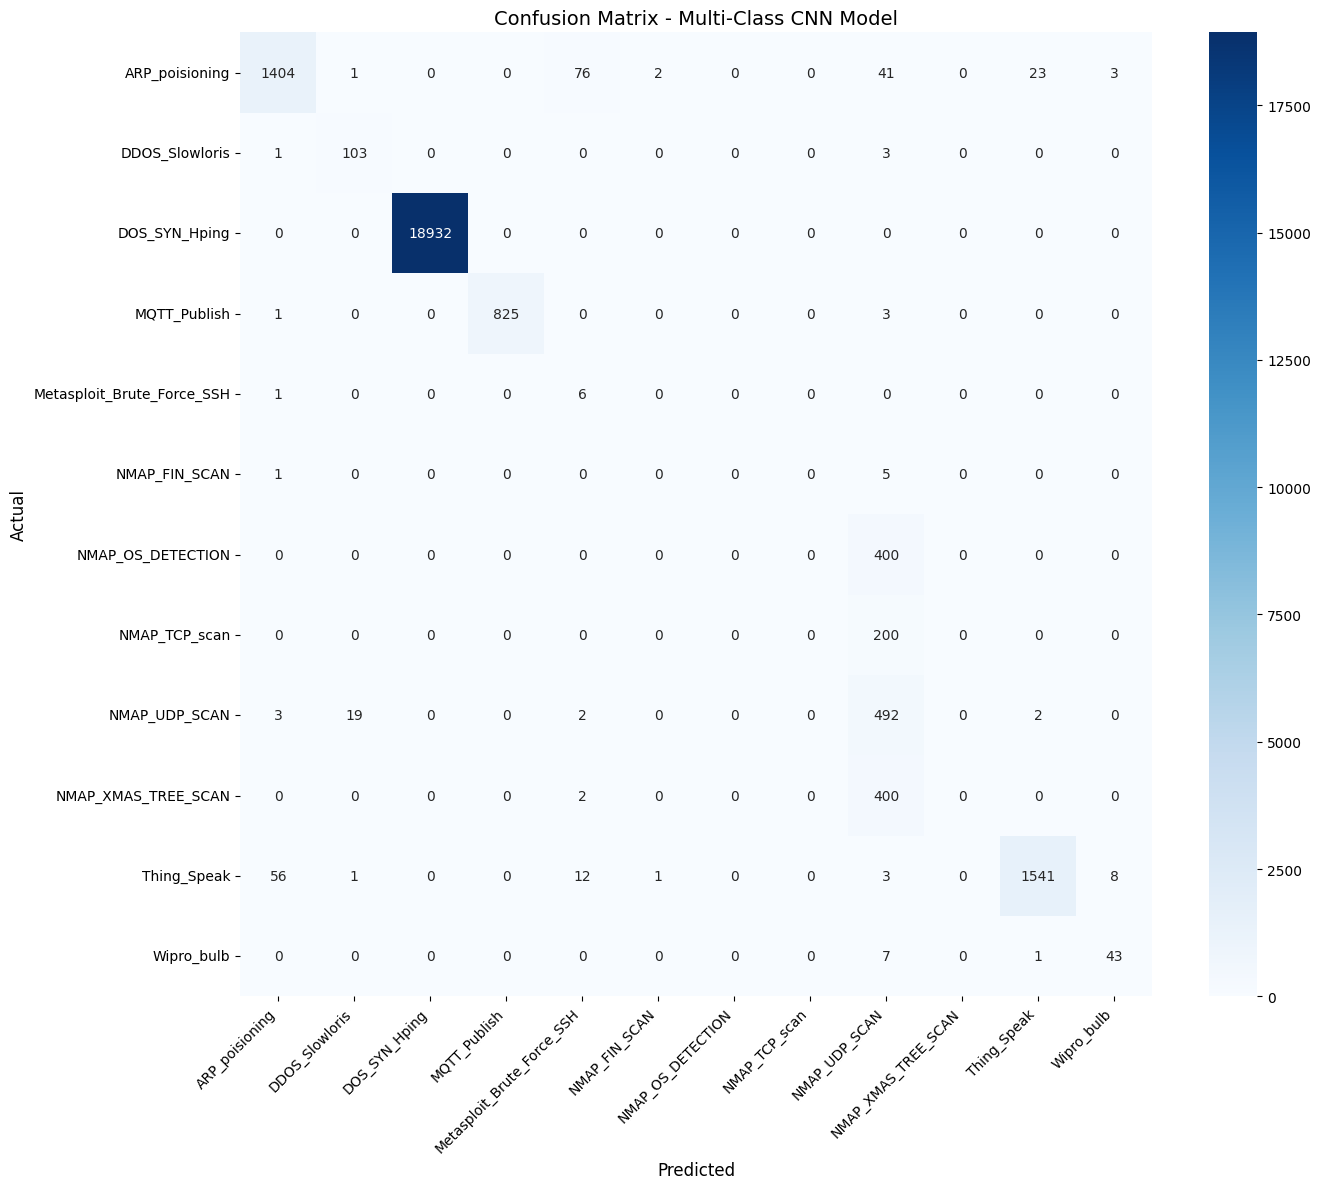

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - Multi-Class CNN Model", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("./2dcnn_multi_conf.png", dpi=600, bbox_inches='tight')
plt.show()

In [ ]:
torch.save(model.state_dict(), "2dcnn_multiclass.pth")
print("Model saved to 2dcnn_multiclass-retrain.pth")

Model saved to 1dcnn_multiclass-retrain.pth
